In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


2026-02-25 11:34:10.925236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772019251.148946      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772019251.213923      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772019251.728794      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772019251.728847      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772019251.728850      17 computation_placer.cc:177] computation placer alr

In [2]:
train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

train.head()
#train.info()

train_ids = np.arange(1, len(train) + 1)
test_ids = np.arange(1, len(test) + 1)

y_train_total = train["label"]
x_train_total = train.drop(["label"], axis =1 )


#scaler_linear = StandardScaler()
#x_train_normalized = scaler_linear.fit_transform(x_train_total)
#x_test_normalized = scaler_linear.fit_transform(test)

x_train_normalized = x_train_total/255
x_test_normalized = test/255

#print(train_ids, x_train)


In [3]:
x_train, x_, y_train, y_ = train_test_split(x_train_normalized, y_train_total, test_size=0.30, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
x_train_cv, x_train_test, y_train_cv, y_train_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

In [4]:
model = keras.Sequential([
    layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.L2(0.0001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.L2(0.0001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.L2(0.0001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

2026-02-25 11:34:43.081079: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot Accuracy
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()



Epoch 1/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7703 - loss: 0.7960 - val_accuracy: 0.9494 - val_loss: 0.2192 - learning_rate: 0.0010
Epoch 2/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9284 - loss: 0.2969 - val_accuracy: 0.9613 - val_loss: 0.1830 - learning_rate: 0.0010
Epoch 3/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9430 - loss: 0.2459 - val_accuracy: 0.9638 - val_loss: 0.1733 - learning_rate: 0.0010
Epoch 4/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9499 - loss: 0.2259 - val_accuracy: 0.9676 - val_loss: 0.1644 - learning_rate: 0.0010
Epoch 5/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9546 - loss: 0.2117 - val_accuracy: 0.9721 - val_loss: 0.1642 - learning_rate: 0.0010
Epoch 6/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9571 - loss: 0.2072 - val_accuracy: 0.9698 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 7/100
919/919 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9586 - loss: 0.

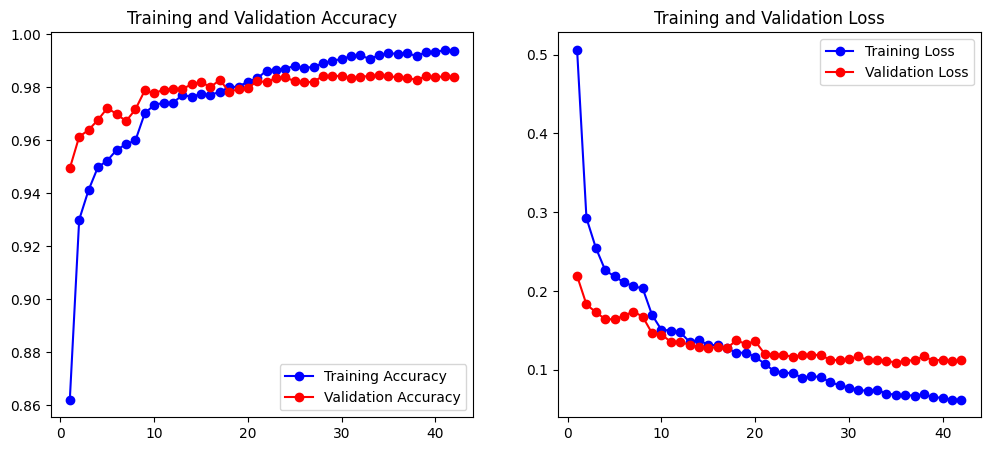

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',   # o que observar
    factor=0.5,           # multiplicador da nova LR
    patience=3,           # quantas épocas esperar
    min_lr=1e-6,          # limite mínimo
    verbose=1
)

history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_train_cv, y_train_cv), callbacks = [reduce_lr, early_stop])

best_epoch = history.history["val_loss"].index(min(history.history["val_loss"]))
print("Best epoch:", best_epoch + 1)
print("Training accuracy at best val_accuracy:", history.history["accuracy"][best_epoch])
print("Validation accuracy:", history.history["val_accuracy"][best_epoch])

plot_history(history)



In [7]:
logits_train = model.predict(x_train_test)
predictions_train = tf.nn.softmax(logits_train).numpy()
predictions_labels_train = np.argmax(predictions_train, axis=1)

print(predictions_labels_train.shape, y_train_test.shape)
accuracy = np.mean(predictions_labels_train == y_train_test)
print(accuracy)

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(6300,) (6300,)
0.9831746031746031


In [8]:
logits = model.predict(x_test_normalized)
predictions = tf.nn.softmax(logits).numpy()
predictions_labels = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [9]:
submission = pd.DataFrame({
    "ImageId": test_ids,
    "Label": predictions_labels
})
print(submission.head())
print(submission.tail())
print(len(submission))
submission.to_csv("submission.csv", index=False)

   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
       ImageId  Label
27995    27996      9
27996    27997      7
27997    27998      3
27998    27999      9
27999    28000      2
28000
